# Radial Basis Function

## Resolvendo o problema XOR com a RBF

In [74]:
#primeira camada escondida - gaussiana
ghu1 <- function(pontos){
    resultado <- exp(-sqrt(sum((pontos-c(1,1))^2))) #distancia até (1,1)
    
    return(resultado)
}

#segunda camada escondida - gaussiana
ghu2 <- function(pontos){
    resultado <- exp(-sqrt(sum((pontos-c(0,0))^2))) #distancia até a origem
    
    return(resultado)
}

In [75]:
 #O problema XOR

# Criando as colunas de entrada (x1 e x2)
x1 <- c(1, 1, 0, 0)
x2 <- c(1, 0, 1, 0)

# Calculando o resultado XOR
# No R, o operador lógico para XOR é a função xor()
y <- as.integer(xor(x1, x2))

# Combinando tudo em uma matriz
matriz_xor <- cbind(x1, x2, y)

# Nomeando as colunas para facilitar a leitura
colnames(matriz_xor) <- c("Input_1", "Input_2", "Output_XOR")

# Exibindo o resultado
print(matriz_xor)

     Input_1 Input_2 Output_XOR
[1,]       1       1          0
[2,]       1       0          1
[3,]       0       1          1
[4,]       0       0          0


In [76]:
#criando o espaço de features - vetor de caracteristicas
#Onde os padrões se tornam linearmente separaveis
novo_espaco_phi <- matrix(nrow=4,ncol=2)

for(i in 1:4){
  novo_espaco_phi[i,] <- c(ghu1(matriz_xor[i,1:2]),ghu2(matriz_xor[i,1:2]))
}

novo_espaco_phi = cbind(novo_espaco_phi, y)
print(novo_espaco_phi)

                         y
[1,] 1.0000000 0.2431167 0
[2,] 0.3678794 0.3678794 1
[3,] 0.3678794 0.3678794 1
[4,] 0.2431167 1.0000000 0


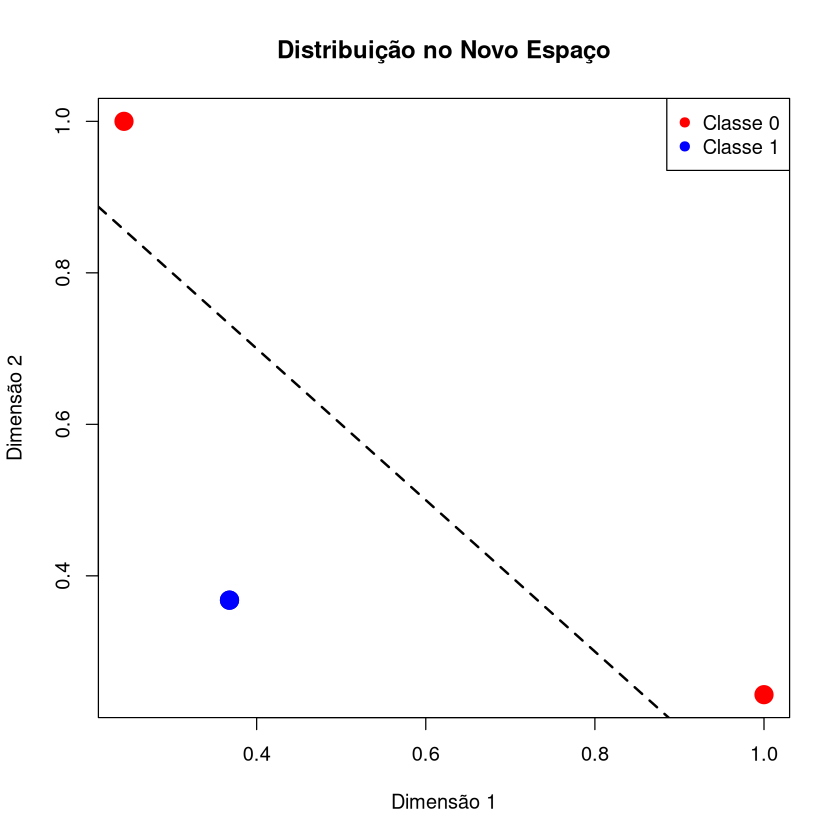

In [77]:
# Plotando os pontos

# Garantindo que a classe seja tratada como fator para cores discretas
cores <- ifelse(novo_espaco_phi[,3] == 1, "blue", "red")

plot(novo_espaco_phi[,1], novo_espaco_phi[,2],
     col = cores,
     pch = 19, # Tipo de ponto preenchido
     cex = 2,  # Tamanho do ponto
     xlab = "Dimensão 1", ylab = "Dimensão 2",
     main = "Distribuição no Novo Espaço")

legend("topright", legend = c("Classe 0", "Classe 1"),
       col = c("red", "blue"), pch = 19)

# Adiciona a reta ao gráfico atual
abline(a = 1.1, b = -1, col = "black", lwd = 2, lty = 2)

## Implementação simples da RBF

$$
\operatorname{D_i}(x) =
\begin{cases}
+1, & x_1 \geq x_2 - 0.25 sin(pi * x_1)\\
-1, & c.c
\end{cases}
$$

In [78]:
# Função que cria o target - a saída desejada Di
target <- function(x1, x2){
  2*(x2-x1 + 0.25*sin(pi*x1) >= 0) - 1
}

In [79]:
# Valores de entrada
N <- 300
X <- data.frame(x1=runif(N,min=-1,max=1),
                x2=runif(N,min=-1,max=1))

In [80]:
print(head(X))

           x1          x2
1 -0.19425712 -0.25820558
2 -0.02779894  0.06011116
3 -0.30640169  0.33606453
4 -0.81635209  0.05531707
5 -0.13929378 -0.87874924
6  0.31569422  0.38598393


In [81]:
# Cria os targets (valores de saída desejados)
Y <- target(X$x1,X$x2)
print(Y)

  [1] -1  1  1  1 -1  1 -1 -1  1  1 -1  1 -1  1  1  1 -1 -1  1 -1 -1 -1 -1  1  1
 [26] -1  1 -1 -1 -1 -1  1 -1  1  1  1 -1  1  1 -1 -1  1 -1  1 -1  1 -1  1  1 -1
 [51]  1  1  1 -1 -1  1 -1  1  1  1 -1 -1  1  1 -1 -1 -1 -1  1  1  1 -1 -1  1 -1
 [76]  1 -1  1 -1  1 -1 -1 -1 -1  1 -1  1 -1  1 -1 -1 -1  1  1 -1 -1  1  1  1  1
[101] -1  1 -1 -1  1 -1  1 -1  1 -1  1 -1 -1  1  1 -1  1 -1  1  1  1 -1 -1 -1 -1
[126] -1 -1 -1 -1 -1  1 -1  1  1 -1  1 -1 -1  1  1 -1 -1  1 -1  1  1 -1  1  1  1
[151] -1 -1  1  1 -1 -1 -1 -1  1  1 -1  1 -1  1 -1  1  1 -1  1 -1 -1  1  1 -1 -1
[176] -1  1  1  1 -1 -1 -1  1  1  1  1 -1 -1  1 -1  1  1 -1  1 -1  1 -1  1  1  1
[201]  1 -1  1  1  1 -1 -1  1  1 -1 -1  1  1 -1 -1  1  1  1 -1  1 -1 -1  1 -1 -1
[226]  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1  1  1  1 -1 -1  1 -1  1  1 -1  1
[251]  1 -1  1  1 -1 -1  1 -1  1 -1 -1 -1 -1 -1  1 -1 -1 -1  1 -1  1  1 -1  1  1
[276] -1  1  1  1  1 -1  1  1 -1  1 -1 -1 -1  1 -1 -1  1  1  1 -1 -1  1  1  1  1


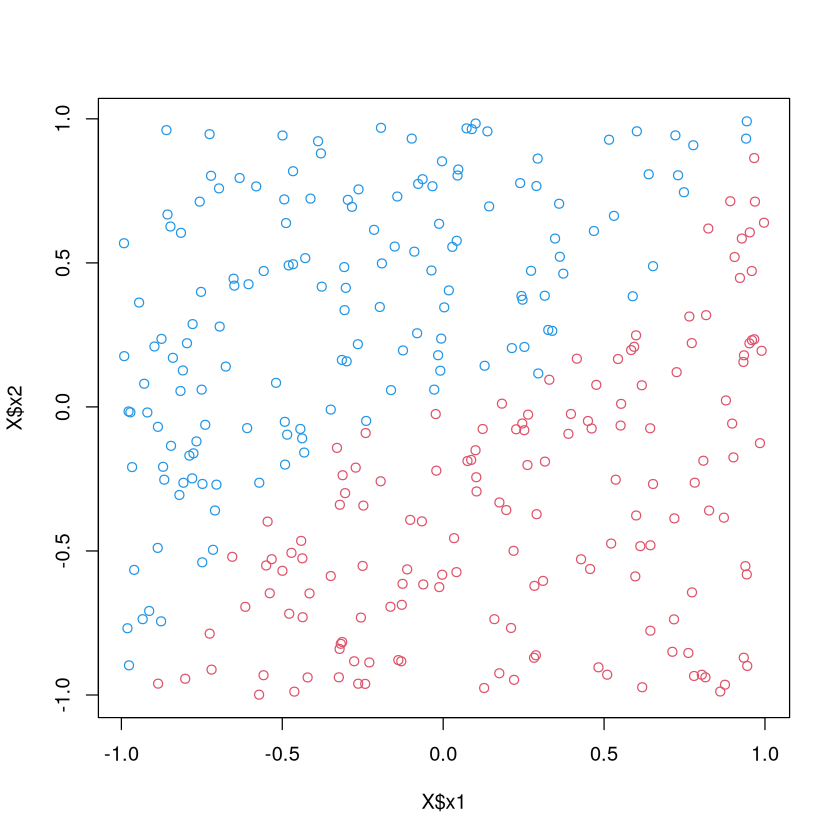

In [82]:
plot(X$x1,X$x2,col=Y+3)

In [83]:
#pacote para estimação de matrizes de covariancia e correlação 
install.packages("corpcor")
library(corpcor)

Installing package into ‘/home/leftlu/R/x86_64-pc-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)



In [84]:
dim(X)[1] #dimensão da matrix X
dim(X)
print(X)

[1] 300

[1] 300   2

              x1           x2
1   -0.194257124 -0.258205581
2   -0.027798938  0.060111165
3   -0.306401686  0.336064534
4   -0.816352088  0.055317074
5   -0.139293776 -0.878749237
6    0.315694216  0.385983935
7    0.725509047  0.120618851
8    0.220285509 -0.947317902
9   -0.788707819 -0.169070884
10  -0.491343179 -0.200219215
11   0.898031122 -0.057791656
12   0.360348872  0.705294997
13  -0.012184142 -0.625472928
14   0.003283363  0.345634165
15   0.468431640  0.610766716
16  -0.377332151  0.417475475
17   0.984399066 -0.125770404
18   0.905682750  0.520383012
19   0.213440472  0.204228129
20  -0.066085096 -0.397283284
21   0.210861350 -0.767315995
22   0.968919257  0.712594233
23  -0.240849266 -0.090638020
24  -0.466492509  0.818179388
25  -0.283408751  0.694463152
26   0.966594677  0.234973349
27  -0.991165289  0.176295035
28   0.599391659  0.248551056
29   0.282326729 -0.870851935
30  -0.250277332 -0.551944155
31  -0.321913097 -0.840076034
32  -0.648986512  0.421043706
33   0.952

In [85]:
k_clusters <- kmeans(X, centers = 10) #define 10 clusters
k_clusters$size # mostra quantos ptos há em cada cluster - sendo cada cluster um neuronio da camada oculta

[1] 32 32 27 22 30 32 26 33 35 31

In [86]:
min(k_clusters$size)
print(k_clusters$centers)

[1] 22

            x1          x2
1  -0.65052378 -0.68286735
2  -0.81919940 -0.02264720
3   0.71828753 -0.70195083
4   0.79935646  0.72530497
5   0.26712220 -0.05914450
6  -0.56357943  0.65635166
7   0.76904726  0.08808353
8  -0.04521154 -0.73225860
9   0.07897388  0.67156133
10 -0.25702775 -0.01607560


In [87]:
K = 10
N = 300
Phi <- matrix(rep(NA,(K+1)*N), ncol=K+1) #matriz de estados 
print(Phi)

       [,1] [,2] [,3] [,4] [,5] [,6] [,7] [,8] [,9] [,10] [,11]
  [1,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
  [2,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
  [3,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
  [4,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
  [5,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
  [6,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
  [7,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
  [8,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
  [9,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
 [10,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
 [11,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
 [12,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
 [13,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
 [14,]   NA   NA   NA   NA   NA   NA   NA   NA   NA    NA    NA
 [15,]   NA   NA   NA   NA   NA   NA   N

In [88]:
rbr.r <- function(X, Y, K=10, gama=1.0){
    N_exe <- dim(X)[1] #numero de exemplos
    ncol <- dim(X)[2] #numero de atributos 

    repeat{
        km <- kmeans(X, K)
        if(min(km$size) > 0){
            break
        }
    }

    #Centros das funções de base radial
    #centroide dos clusters
    centroide <- km$centers

    #saida das gaussianas
    Phi <- matrix(rep(NA, (K+1)*N_exe), ncol=K+1)

    for(lin in 1:N_exe){
        Phi[lin,1] <- 1
        for(col in 1:K){
            Phi[lin, col+1] <- exp( (-1/(2*gama*gama)) *
                        sum( (X[lin,]-centroide[col,])*(X[lin,]-centroide[col,]) ) )
        }
    }

    #calcula os pesos
    #%*% = produto de MATRIZES
    w <- pseudoinverse(t(Phi) %*% Phi) %*% t(Phi) %*% Y

    modelo = list(phi= Phi, pesos=w, centros=centroide, gama=gama)

    return(modelo)
}

In [89]:
#aplicando a arq no modelo
modelo <- rbr.r(X, Y, K=10)

In [90]:
#verificando o tamanho
length(modelo$centros[,1])

[1] 10

In [91]:
modelo$phi

1,0.4220719,0.9747906,0.8073614,0.6375673,0.9015550,0.8335248,0.7998383,0.5383530,0.6143899,0.6099041
1,0.6109178,0.9778344,0.7351369,0.6935650,0.7915180,0.6314209,0.9224096,0.4901282,0.7227959,0.8087861
1,0.5148362,0.9303427,0.8251702,0.4693476,0.5888912,0.5457601,0.7716159,0.2845635,0.9176979,0.8784503
1,0.2287023,0.8326756,0.9963730,0.2747957,0.5300320,0.7101893,0.4928660,0.1951233,0.8120003,0.5594783
1,0.2191258,0.6974393,0.5578409,0.5631748,0.9402374,0.9032438,0.5455002,0.6721606,0.2815203,0.2794087
1,0.8645974,0.7943454,0.4883766,0.7243118,0.5917237,0.3622510,0.9572847,0.4263764,0.6499723,0.9144214
1,0.8976821,0.6333553,0.3055106,0.9199137,0.6243974,0.3014800,0.9393108,0.6272418,0.3733563,0.6659627
1,0.2619524,0.5983939,0.3871037,0.6973281,0.9378448,0.7172763,0.5735800,0.8638997,0.2027783,0.2500910
1,0.2075614,0.8418098,0.9901297,0.3020798,0.6155400,0.8320112,0.4919677,0.2430838,0.6968104,0.4823741
1,0.3129822,0.9499592,0.9375838,0.4587198,0.7751851,0.8651001,0.6590250,0.3753044,0.6924710,0.5745149
1,0.8159252,0.5364600,0.2335840,0.9640402,0.6185634,0.2724306,0.8607789,0.7257886,0.2631319,0.5167800


In [92]:
print(modelo$pesos)

             [,1]
 [1,]   0.1309727
 [2,]  -6.8606884
 [3,] -17.4246330
 [4,]  15.3682923
 [5,] -16.4313660
 [6,]  -3.6412985
 [7,]  -2.5884838
 [8,]  23.1682168
 [9,]   9.5429565
[10,]  -9.8069501
[11,]   8.5047969


In [93]:
# Função de predição
rbf.predict <- function(modelo,X,classification=FALSE){

  gama <- modelo$gama
  centros <- modelo$centros
  w <- modelo$pesos
  N <- dim(X)[1]

  pred <- rep(w[1],N)

  for(j in 1:N){
    # Predicação para o ponto x_j
    for(k in 1:length(centros[,1])){
      pred[j] <- pred[j] + w[k+1] * exp( (-1/(2*gama*gama)) *
                        sum( (X[j,]-centros[k,])*(X[j,]-centros[k,])) )
    }
  }

  if(classification){
    pred <- unlist(lapply(pred,sign))
  }

  return(pred)
}

In [94]:
pred <- c(-0.5,45,-34,345,-90)
print(pred)

[1]  -0.5  45.0 -34.0 345.0 -90.0


In [95]:
print(unlist(lapply(pred,sign))) # limita entre -1 e 1 usando s funcao degrau

[1] -1  1 -1  1 -1


In [96]:
# Exemplos de teste
N.test <- 200
X.test <- data.frame(x1=runif(N.test,min=-1,max=1),
                     x2=runif(N.test,min=-1,max=1))
Y.test <- target(X.test$x1, X.test$x2)
print(head(X.test))

            x1          x2
1 -0.004507667  0.94545990
2 -0.418298862  0.66075909
3  0.435604936 -0.70651615
4 -0.451954326 -0.40299318
5 -0.613850605 -0.91372892
6  0.155767978  0.08673567


In [97]:
rbf.pred <- rbf.predict(modelo,X.test, classification=TRUE)

In [98]:
rbf.pred

[1]  1  1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1 -1  1  1  1  1  1 -1
 [26]  1  1 -1 -1 -1 -1  1  1  1  1 -1 -1  1  1  1  1 -1 -1 -1 -1  1 -1 -1  1  1
 [51]  1 -1 -1  1  1 -1  1  1 -1  1  1  1  1 -1 -1  1 -1  1 -1  1 -1  1  1 -1 -1
 [76]  1 -1  1  1  1  1 -1 -1 -1 -1 -1 -1  1  1  1 -1  1 -1 -1 -1  1  1  1 -1 -1
[101] -1 -1 -1  1 -1 -1  1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1  1  1  1  1 -1 -1 -1
[126]  1 -1  1  1  1  1 -1  1 -1  1 -1 -1  1 -1 -1 -1  1  1 -1 -1  1  1  1  1  1
[151]  1  1 -1 -1 -1 -1 -1  1 -1 -1  1  1  1  1 -1  1 -1  1 -1 -1 -1  1  1 -1  1
[176] -1  1 -1  1 -1 -1 -1 -1 -1  1  1  1  1 -1 -1  1  1  1  1  1 -1 -1 -1 -1 -1

In [99]:
erro <- sum(rbf.pred != Y.test) / N.test # porcentagem de erro 
erro

[1] 0.025

In [100]:
sum(rbf.pred != Y.test) # quantos erros houveram

[1] 5

In [101]:
#matriz de confusão - mostra acertos e erros
mf <- table(rbf.pred,Y.test)
mf

        Y.test
rbf.pred  -1   1
      -1 104   1
      1    4  91

In [102]:
sum(diag(mf)) / sum(mf)

[1] 0.975

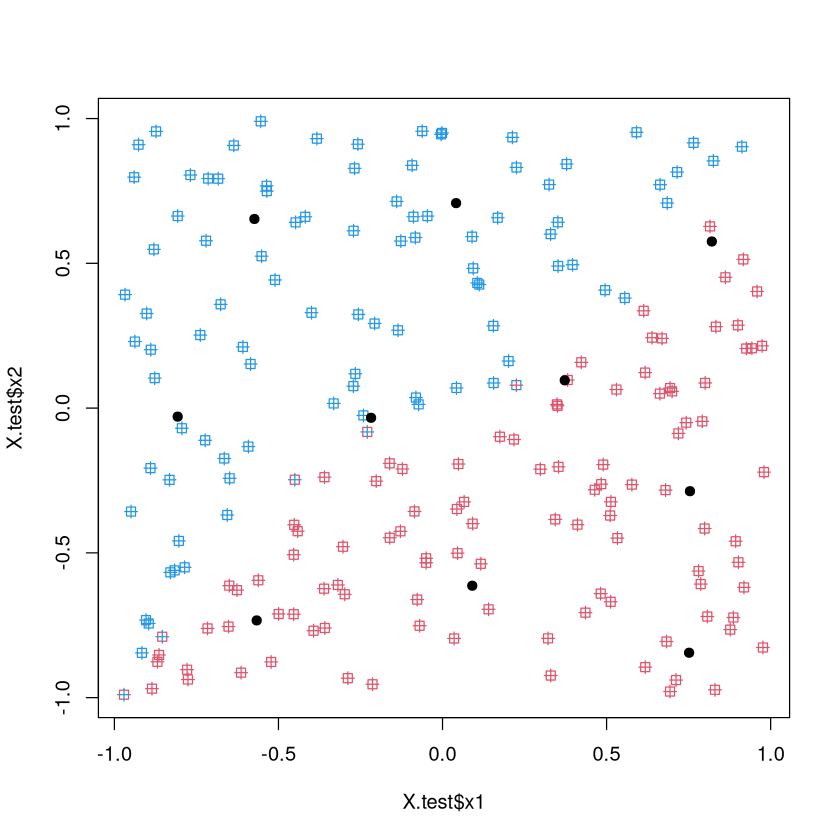

In [104]:
#Visualizando os dados e os centros dos clusters
plot(X.test$x1, X.test$x2, col=Y.test+3, pch=0)
points(X.test$x1, X.test$x2, col=rbf.pred+3, pch=3)
points(modelo$centros, col="black", pch=19)

## Utilizando a biblioteca pronta

In [105]:
install.packages("RSNNS")
#library(RSNNS)

Installing package into ‘/home/leftlu/R/x86_64-pc-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)

also installing the dependency ‘Rcpp’




In [106]:
library(RSNNS)

Carregando pacotes exigidos: Rcpp



In [108]:
?rbf

rbf                   package:RSNNS                    R Documentation

_C_r_e_a_t_e _a_n_d _t_r_a_i_n _a _r_a_d_i_a_l _b_a_s_i_s _f_u_n_c_t_i_o_n (_R_B_F) _n_e_t_w_o_r_k

_D_e_s_c_r_i_p_t_i_o_n:

     The use of an RBF network is similar to that of an ‘mlp’.  The
     idea of radial basis function networks comes from function
     interpolation theory. The RBF performs a linear combination of n
     basis functions that are radially symmetric around a
     center/prototype.

_U_s_a_g_e:

     rbf(x, ...)
     
     ## Default S3 method:
     rbf(
       x,
       y,
       size = c(5),
       maxit = 100,
       initFunc = "RBF_Weights",
       initFuncParams = c(0, 1, 0, 0.02, 0.04),
       learnFunc = "RadialBasisLearning",
       learnFuncParams = c(1e-05, 0, 1e-05, 0.1, 0.8),
       updateFunc = "Topological_Order",
       updateFuncParams = c(0),
       shufflePatterns = TRUE,
       linOut = TRUE,
       inputsTest = NU

In [109]:
rbf.model <- RSNNS::rbf(as.matrix(X,ncol=2),
                 as.matrix(Y),
                 size=10,
                 maxit=1000,
                 linOut=TRUE)

In [110]:
rbf.prediction <- sign(predict(rbf.model,X.test))
print(rbf.prediction)

       [,1]
  [1,]    1
  [2,]    1
  [3,]   -1
  [4,]   -1
  [5,]   -1
  [6,]   -1
  [7,]   -1
  [8,]   -1
  [9,]   -1
 [10,]   -1
 [11,]   -1
 [12,]   -1
 [13,]   -1
 [14,]   -1
 [15,]   -1
 [16,]    1
 [17,]    1
 [18,]    1
 [19,]   -1
 [20,]    1
 [21,]    1
 [22,]    1
 [23,]   -1
 [24,]    1
 [25,]   -1
 [26,]    1
 [27,]    1
 [28,]   -1
 [29,]   -1
 [30,]   -1
 [31,]   -1
 [32,]    1
 [33,]    1
 [34,]    1
 [35,]    1
 [36,]   -1
 [37,]   -1
 [38,]    1
 [39,]    1
 [40,]    1
 [41,]    1
 [42,]   -1
 [43,]   -1
 [44,]   -1
 [45,]   -1
 [46,]    1
 [47,]   -1
 [48,]   -1
 [49,]    1
 [50,]    1
 [51,]   -1
 [52,]   -1
 [53,]   -1
 [54,]    1
 [55,]    1
 [56,]   -1
 [57,]    1
 [58,]    1
 [59,]   -1
 [60,]    1
 [61,]   -1
 [62,]    1
 [63,]    1
 [64,]   -1
 [65,]   -1
 [66,]    1
 [67,]   -1
 [68,]    1
 [69,]   -1
 [70,]    1
 [71,]   -1
 [72,]    1
 [73,]    1
 [74,]   -1
 [75,]   -1
 [76,]    1
 [77,]   -1
 [78,]    1
 [79,]    1
 [80,]    1
 [81,]    1
 [82,]   -1
 [83

In [111]:
erro <- sum(rbf.prediction != Y.test) / N.test
erro

[1] 0.05

In [112]:
summary(rbf.model)

SNNS network definition file V1.4-3D
generated at Wed Mar 18 16:11:14 2026

network name : RSNNS_untitled
source files :
no. of units : 13
no. of connections : 30
no. of unit types : 0
no. of site types : 0


learning function : RadialBasisLearning
update function   : Topological_Order


unit default section :

act      | bias     | st | subnet | layer | act func     | out func
---------|----------|----|--------|-------|--------------|-------------
 0.00000 |  0.00000 | i  |      0 |     1 | Act_Logistic | Out_Identity 
---------|----------|----|--------|-------|--------------|-------------


unit definition section :

no. | typeName | unitName    | act      | bias     | st | position | act func             | out func | sites
----|----------|-------------|----------|----------|----|----------|----------------------|----------|-------
  1 |          | Input_1     |  0.69335 |  0.00000 | i  |  1, 0, 0 | Act_Identity         |          | 
  2 |          | Input_2     | -0.97899 |  0.00000

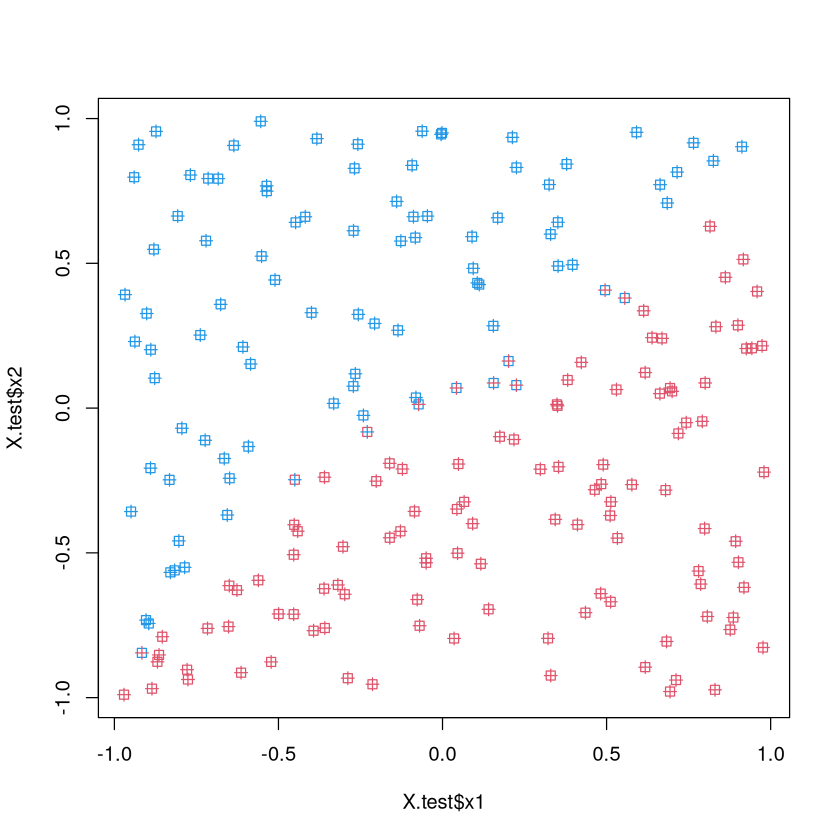

In [113]:
plot(X.test$x1, X.test$x2, col=Y.test+3, pch=0)
points(X.test$x1, X.test$x2, col=rbf.prediction+3, pch=3)